<a href="https://colab.research.google.com/github/Dracarys38/Machyne-navchanya/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%969_%D0%9C%D0%9D%2C_%D0%9F%D0%BE%D1%81%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D1%8F%D0%BA_%D0%86%D0%B3%D0%BE%D1%80_%D0%A1%D0%B5%D1%80%D0%B3%D1%96%D0%B9%D0%BE%D0%B2%D0%B8%D1%87_%D0%A4%D0%86%D0%A2_3_15%2C_10_%D0%B2%D0%B0%D1%80%D1%96%D0%B0%D0%BD%D1%82_%D0%A0%D0%A1%D0%90(%D0%A7%D0%B0%D1%81%D1%82%D0%B8%D0%BD%D0%B0_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import kagglehub
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
import os

In [2]:
path = kagglehub.dataset_download("brunogrisci/leukemia-gene-expression-cumida")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'leukemia-gene-expression-cumida' dataset.
Path to dataset files: /kaggle/input/leukemia-gene-expression-cumida


In [3]:
df = pd.read_csv(os.path.join(path, "Leukemia_GSE9476.csv"))
df

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Hs28SrRNA-5_at,AFFX-r2-Hs28SrRNA-M_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,1,Bone_Marrow_CD34,7.745245,7.811210,6.477916,8.841506,4.546941,7.957714,5.344999,4.673364,...,5.058849,6.810004,12.800060,12.718612,5.391512,4.666166,3.974759,3.656693,4.160622,4.139249
1,12,Bone_Marrow_CD34,8.087252,7.240673,8.584648,8.983571,4.548934,8.011652,5.579647,4.828184,...,4.436153,6.751471,12.472706,12.333593,5.379738,4.656786,4.188348,3.792535,4.204414,4.122700
2,13,Bone_Marrow_CD34,7.792056,7.549368,11.053504,8.909703,4.549328,8.237099,5.406489,4.615572,...,4.392061,6.086295,12.637384,12.499038,5.316604,4.600566,3.845561,3.635715,4.174199,4.067152
3,14,Bone_Marrow_CD34,7.767265,7.094460,11.816433,8.994654,4.697018,8.283412,5.582195,4.903684,...,4.633334,6.375991,12.903630,12.871454,5.179951,4.641952,3.991634,3.704587,4.149938,3.910150
4,15,Bone_Marrow_CD34,8.010117,7.405281,6.656049,9.050682,4.514986,8.377046,5.493713,4.860754,...,5.305192,6.700453,12.949352,12.782515,5.341689,4.560315,3.887020,3.629853,4.127513,4.004316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,60,PBSC_CD34,7.686106,6.856961,6.822222,8.849700,4.440703,8.456949,5.408897,4.708615,...,4.969400,7.016576,12.997293,12.828832,5.084120,4.531087,3.884230,3.619301,4.108490,4.070028
60,61,PBSC_CD34,7.816168,6.875124,6.532324,8.827857,4.515457,8.450286,5.482797,4.667874,...,4.826255,6.577223,12.990305,12.855352,5.260451,4.568651,3.927693,3.634879,4.112277,4.064780
61,62,PBSC_CD34,7.863092,6.896242,6.630690,8.775139,4.458048,8.664517,5.577298,4.853996,...,5.065816,6.583261,12.786121,12.588852,5.451940,4.739944,4.010427,3.668713,4.162220,4.102264
62,63,PBSC_CD34,7.900992,6.787515,6.642927,8.856187,4.499548,9.188459,5.471110,4.637444,...,4.985061,6.815527,13.020089,12.824868,5.459571,4.602105,4.019624,3.570563,4.141371,4.102641


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Columns: 22285 entries, samples to AFFX-TrpnX-M_at
dtypes: float64(22283), int64(1), object(1)
memory usage: 10.9+ MB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
target = df["type"]
target.value_counts()

,count
type,
AML,26
PB,10
Bone_Marrow,10
PBSC_CD34,10
Bone_Marrow_CD34,8


In [7]:
data = df.drop(columns=["samples", "type"])

z_scores = data.apply(zscore).abs()

outliers_mask = z_scores > 3

outlier_fraction = outliers_mask.mean(axis=1)

outlier_indices = outlier_fraction[outlier_fraction > 0.2].index

df = df.drop(index=outlier_indices)
target = target.drop(index=outlier_indices)

In [8]:
df.shape

(64, 22285)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    data,
    target,
    test_size=0.2,
    random_state=42
)

In [10]:
scaler = StandardScaler().set_output(transform='pandas')

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
pca = PCA().set_output(transform='pandas').fit(X_train)

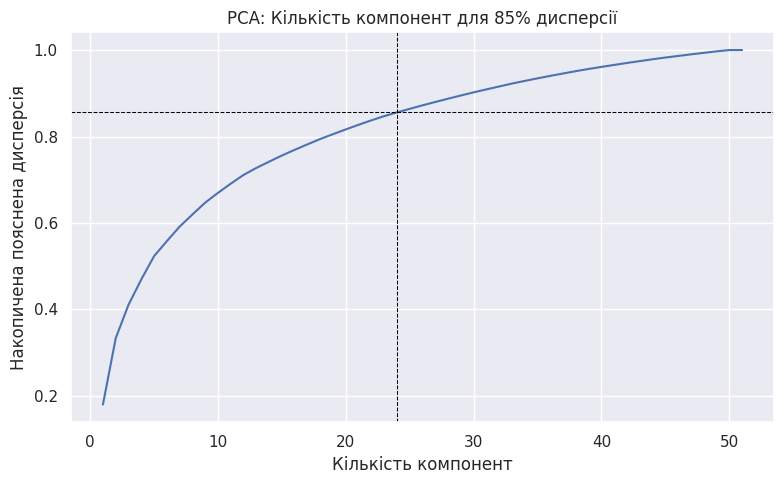

In [12]:
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Створення графіка
sns.set_theme()
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(x=np.arange(1, len(explained_variance) + 1), y=explained_variance, ax=ax)

ax.set(
    xlabel='Кількість компонент',
    ylabel='Накопичена пояснена дисперсія',
    title='PCA: Кількість компонент для 85% дисперсії'
)

# Знаходимо кількість компонент, достатню для 85%
n_components = np.searchsorted(explained_variance, 0.85) + 1  # +1 бо індексація з 0

# Вертикальна і горизонтальна лінії
ax.axvline(x=n_components, color='black', linestyle='--', linewidth=0.75)
ax.axhline(y=explained_variance[n_components - 1], color='black', linestyle='--', linewidth=0.75)

plt.tight_layout()
plt.show()

In [13]:
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

In [14]:
X_train_pca.iloc[:, :n_components].head()

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,...,pca14,pca15,pca16,pca17,pca18,pca19,pca20,pca21,pca22,pca23
13,16.820999,34.903574,-0.890093,11.339648,41.858329,-43.650248,19.498081,-38.811836,3.569116,-3.708797,...,-4.926885,-4.775903,-9.667523,-1.280651,12.311428,1.945766,-2.897287,-12.958723,-8.618061,4.344385
34,44.894760,-12.157780,-57.720991,53.716727,-62.184216,-22.503680,17.746703,3.415854,19.813474,21.489266,...,79.838325,-3.788930,15.092687,-29.132727,17.134900,-4.434168,-14.445294,-0.041625,-10.276779,0.389676
50,-24.682635,131.334127,9.749087,-3.021057,-19.243698,-6.702661,0.440195,29.895475,4.879099,4.985307,...,0.839195,8.904300,-4.982312,3.954331,7.133173,4.702663,-6.966067,23.984453,-4.821261,-2.230078
3,40.891589,-64.783435,-16.635704,-27.814461,41.382949,-5.982859,-8.663965,39.164372,-1.307748,20.488950,...,-8.783102,-2.645770,-6.764236,4.933173,44.976101,-11.261858,11.582371,-10.032525,7.644777,6.329901
17,15.649074,37.946291,15.427679,18.151486,43.914519,-32.950138,-0.674742,-22.158600,5.028498,-30.223438,...,0.487636,-7.279847,-1.405508,-3.530243,-5.739945,-0.903455,2.138695,5.399026,-3.720250,-5.876050


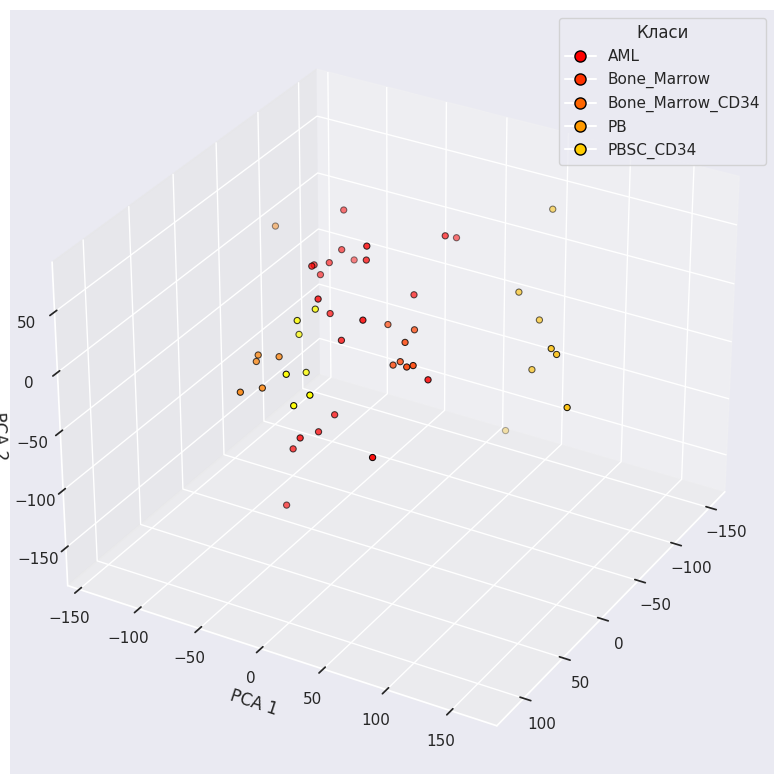

In [15]:
# Перетворимо PCA-результати у DataFrame
pca_df = pd.DataFrame(
    X_train_pca,
    columns=[f"pca{i}" for i in range(X_train_pca.shape[1])],
    index=y_train.index # індекс важливо зберегти
)

# Закодуємо текстові мітки класів у числа
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

# Побудуємо 3D-графік
plt.figure(figsize=(8, 8))
ax = plt.subplot(projection='3d')

scatter = ax.scatter3D(
    pca_df["pca0"],
    pca_df["pca1"],
    pca_df["pca2"],
    c=y_train_encoded,
    cmap='autumn',
    s=20,
    edgecolor='black',
    linewidth=0.75
)

# Оформлення графіка
ax.set_ylabel("PCA 1")
ax.set_zlabel("PCA 2")
ax.view_init(elev=30, azim=30)

# Кольори для кожного класу
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=label,
           markerfacecolor=plt.cm.autumn(i / len(label_encoder.classes_)),
           markeredgecolor='black', markersize=8)
    for i, label in enumerate(label_encoder.classes_)
]

ax.legend(handles=legend_elements, title="Класи", loc='best')

# 6. Показуємо
plt.tight_layout()
plt.show()

In [16]:
clf_full = HistGradientBoostingClassifier(max_iter=50, random_state=42)
clf_full.fit(X_train, y_train)

HistGradientBoostingClassifier(max_iter=50, random_state=42)

In [17]:
clf_pca = GradientBoostingClassifier()

clf_pca.fit(X_train_pca.iloc[:, :n_components], y_train)

pred_pca = clf_pca.predict(X_test_pca.iloc[:, :n_components])

score_pca = accuracy_score(y_test, pred_pca)

print(f'Model accuracy (PCA): {score_pca:.1%}')

Model accuracy (PCA): 69.2%


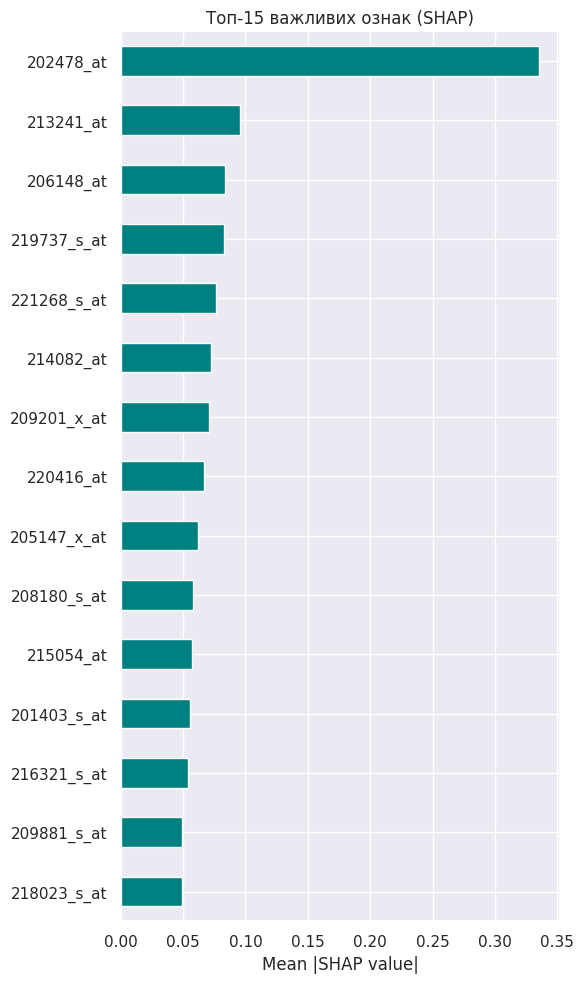

In [18]:
import shap
import numpy as np

explainer = shap.TreeExplainer(clf_full)
shap_values = explainer.shap_values(X_train)

if shap_values.ndim == 3:
    mean_shap = np.abs(shap_values).mean(axis=(0, 2))
elif shap_values.ndim == 2:
    mean_shap = np.abs(shap_values).mean(axis=0)

importances = pd.Series(data=mean_shap, index=X_train.columns)

top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(6, 10))
top_features.sort_values().plot.barh(color='teal')
plt.title("Топ-15 важливих ознак (SHAP)")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

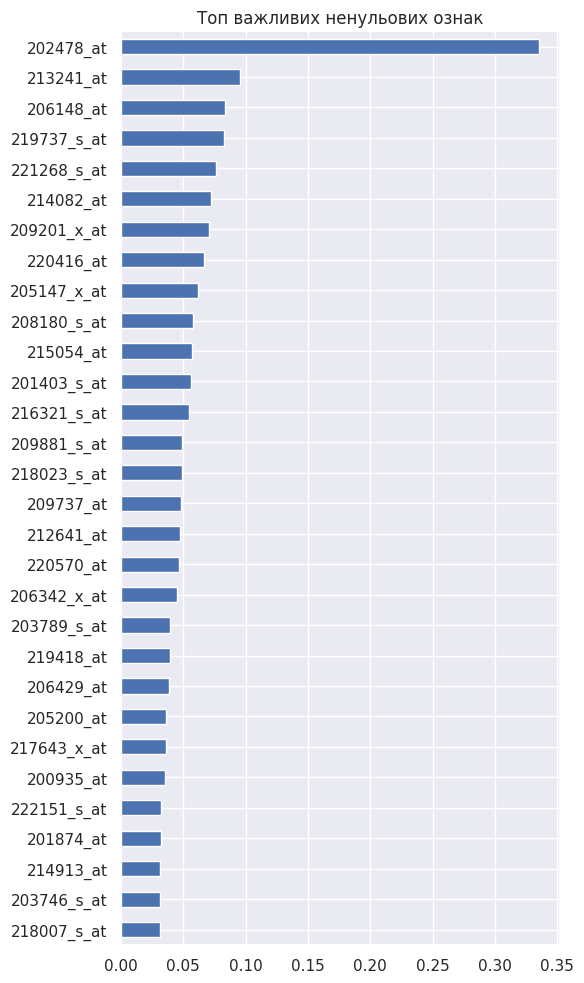

In [19]:
nonzero = importances[importances > 0]
top = nonzero.sort_values(ascending=False).head(30)

plt.figure(figsize=(6, 10))
top.sort_values().plot.barh()
plt.title("Топ важливих ненульових ознак")
plt.tight_layout()
plt.show()